In [29]:
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import Conv2D, Flatten,MaxPooling2D,UpSampling2D
from tensorflow.keras.layers import Reshape, Conv2DTranspose
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend as K
from tensorflow import keras

In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:
(x_train, _), (x_test, _) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


In [4]:
x_train.shape

(50000, 32, 32, 3)

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
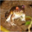

In [5]:
x_train[0]

In [6]:
# x_train = np.reshape(x_train, (-1, x_train.shape[1], x_train.shape[1]))
# x_test = np.reshape(x_test, (-1, x_test.shape[1], x_test.shape[1]))
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [7]:
input_shape = (32, 32, 3)
batch_size = 32
kernel_size = 3

In [20]:
inputs = Input(shape=input_shape)
x = inputs
x = Conv2D(filters=32, kernel_size=kernel_size, activation='relu', strides=1,)(x)
x = Conv2D(filters=64, kernel_size=kernel_size, activation='relu', strides=1, )(x)
x = Conv2D(filters=64, kernel_size=kernel_size, activation='relu', strides=1)(x)
x = MaxPooling2D((2,2))(x)

shape = K.int_shape(x)
x = Flatten()(x)
h = Dense(100)(x)

encoder = Model(inputs, h)

In [21]:
encoder.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 28, 28, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 26, 26, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 10816)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 100)                 │       1,081,700 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,138,020 (4.34 MB)

 Trainable params: 1,138,020 (4.34 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
h_inputs = Input(shape=[100])
x = Dense(shape[1] * shape[2] * shape[3])(h_inputs)

x = Reshape((shape[1], shape[2], shape[3]))(x)
x = UpSampling2D((2,2))(x)
x = Conv2DTranspose(filters=64, kernel_size=kernel_size, activation='relu', strides=1)(x)
x = Conv2DTranspose(filters=32, kernel_size=kernel_size, activation='relu', strides=1)(x)
outputs = Conv2DTranspose(filters=3, kernel_size=kernel_size, activation='sigmoid', strides=1, )(x)

decoder = Model(h_inputs, outputs)

In [23]:
decoder.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10816)               │       1,092,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_1 (Reshape)                  │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_3 (Conv2DTranspose) │ (None, 28, 28, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_4 (Conv2DTranspose) │ (None, 30, 30, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_5 (Conv2DTranspose) │ (None, 32, 32, 3)           │             867 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,148,675 (4.38 MB)

 Trainable params: 1,148,675 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
autoencoder = Model(inputs, decoder(encoder(inputs)))
autoencoder.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ functional_4 (Functional)            │ (None, 100)                 │       1,138,020 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ functional_5 (Functional)            │ (None, 32, 32, 3)           │       1,148,675 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,286,695 (8.72 MB)

 Trainable params: 2,286,695 (8.72 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
autoencoder.compile(loss='mse', optimizer='adam')

In [26]:
autoencoder.fit(x_train, x_train, validation_data=(x_test, x_test), epochs=5, batch_size=batch_size)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0214 - val_loss: 0.0068
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 0.0065 - val_loss: 0.0060
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0.0059 - val_loss: 0.0059
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0.0058 - val_loss: 0.0058
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0.0057 - val_loss: 0.0057


In [27]:
x_decoded = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


<ipython-input-28-baf348a69cc2>:3: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax1 = plt.subplot(2,4,1)


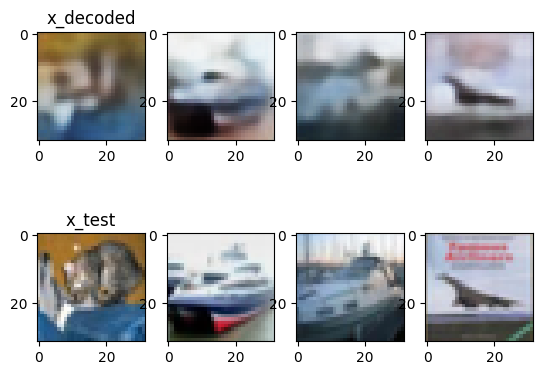

In [28]:
plt.figure()
plt.title("x_decode")
ax1 = plt.subplot(2,4,1)
ax1.title.set_text('x_decoded')
plt.imshow(x_decoded[0], cmap='gray')
plt.subplot(2,4,2)
plt.imshow(x_decoded[1], cmap='gray')
plt.subplot(2,4,3)
plt.imshow(x_decoded[2], cmap='gray')
plt.subplot(2,4,4)
plt.imshow(x_decoded[3], cmap='gray')
ax2 = plt.subplot(2,4,5)
ax2.title.set_text('x_test')
plt.imshow(x_test[0], cmap='gray')
plt.subplot(2,4,6)
plt.imshow(x_test[1], cmap='gray')
plt.subplot(2,4,7)
plt.imshow(x_test[2], cmap='gray')
plt.subplot(2,4,8)
plt.imshow(x_test[3], cmap='gray')

# Method 2

In [30]:
input_shape

(32, 32, 3)

In [42]:
model2 = Sequential()
model2.add(Conv2D(filters=32, kernel_size=kernel_size, activation='relu', strides=1, input_shape=input_shape ))
model2.add(Conv2D(filters=64, kernel_size=kernel_size, activation='relu', strides=1))
model2.add(Conv2D(filters=64, kernel_size=kernel_size, activation='relu', strides=1 ))


max1 = model2.add(MaxPooling2D((2,2),name='max1'))

shape = [None,13, 13, 64]
model2.add(Flatten())
model2.add(Dense(300,name='features'))
# Decoder
model2.add(Dense(shape[1] * shape[2] * shape[3]))

model2.add(Reshape((shape[1], shape[2], shape[3])))
model2.add(UpSampling2D((2,2)))
model2.add(Conv2DTranspose(filters=64, kernel_size=kernel_size, activation='relu', strides=1))
model2.add(Conv2DTranspose(filters=32, kernel_size=kernel_size, activation='relu', strides=1))
model2.add(Conv2DTranspose(filters=3, kernel_size=kernel_size, activation='sigmoid', strides=1, ))

model2.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)                   │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_31 (Conv2D)                   │ (None, 28, 28, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_32 (Conv2D)                   │ (None, 26, 26, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max1 (MaxPooling2D)                  │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 10816)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ features (Dense)                     │ (None, 300)                 │       3,245,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10816)               │       3,255,616 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_3 (Reshape)                  │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_2 (UpSampling2D)       │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_9 (Conv2DTranspose) │ (None, 28, 28, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_10                  │ (None, 30, 30, 32)          │          18,464 │
│ (Conv2DTranspose)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_11                  │ (None, 32, 32, 3)           │             867 │
│ (Conv2DTranspose)                    │                             │                 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,613,295 (25.23 MB)

 Trainable params: 6,613,295 (25.23 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model2.compile(loss='mse', optimizer='adam')

In [44]:
model2.fit(x_train, x_train, validation_data=(x_test, x_test), epochs=5, batch_size=batch_size)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 0.0182 - val_loss: 0.0056
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - loss: 0.0049 - val_loss: 0.0041
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0038 - val_loss: 0.0034
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.0033 - val_loss: 0.0030
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 0.0029 - val_loss: 0.0029


In [45]:
x_decoded = model2.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


<ipython-input-46-baf348a69cc2>:3: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax1 = plt.subplot(2,4,1)


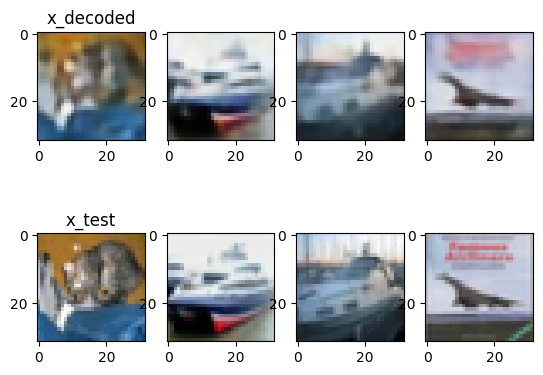

In [46]:
plt.figure()
plt.title("x_decode")
ax1 = plt.subplot(2,4,1)
ax1.title.set_text('x_decoded')
plt.imshow(x_decoded[0], cmap='gray')
plt.subplot(2,4,2)
plt.imshow(x_decoded[1], cmap='gray')
plt.subplot(2,4,3)
plt.imshow(x_decoded[2], cmap='gray')
plt.subplot(2,4,4)
plt.imshow(x_decoded[3], cmap='gray')
ax2 = plt.subplot(2,4,5)
ax2.title.set_text('x_test')
plt.imshow(x_test[0], cmap='gray')
plt.subplot(2,4,6)
plt.imshow(x_test[1], cmap='gray')
plt.subplot(2,4,7)
plt.imshow(x_test[2], cmap='gray')
plt.subplot(2,4,8)
plt.imshow(x_test[3], cmap='gray')